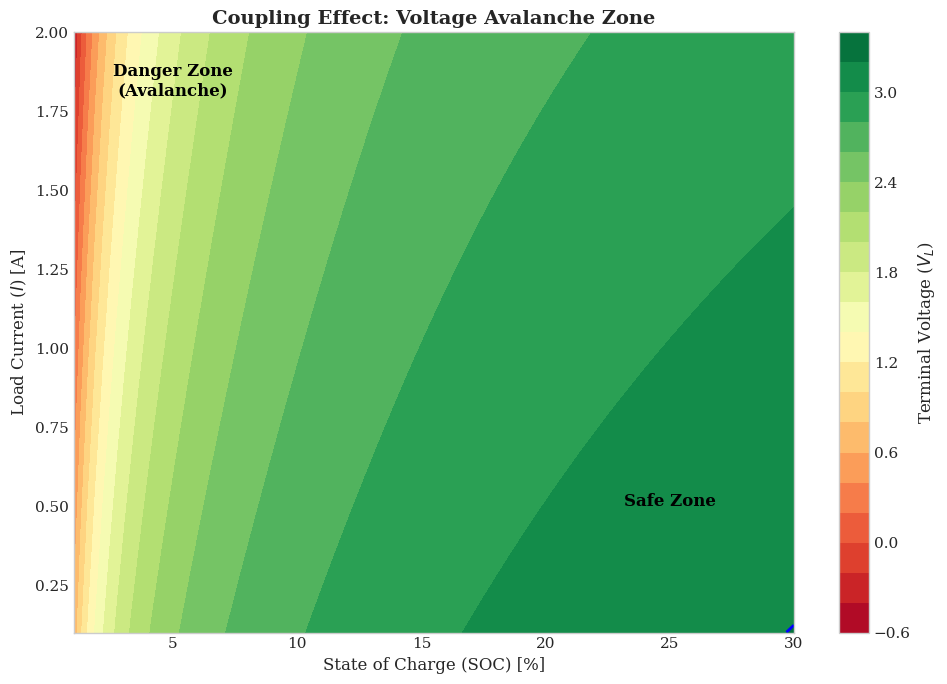

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 模拟数据范围
soc_range = np.linspace(0.01, 0.30, 100)  # SOC 1% 到 30%
current_range = np.linspace(0.1, 2.0, 100) # 电流 0.1A 到 2.0A
SOC, I = np.meshgrid(soc_range, current_range)

# 定义简化的物理模型 (基于您论文中的公式)
# OCV 随 SOC 降低而降低
V_ocv = 3.2 + 0.6 * SOC - 0.05 / (SOC + 0.01) 
# 内阻 R 随 SOC 降低呈指数升高 (Equation 14)
R_total = 0.15 + 0.5 * np.exp(-20 * SOC) 

# 计算端电压 V_L = OCV - I * R
V_term = V_ocv - I * R_total

# 绘图
fig, ax = plt.subplots(figsize=(10, 7))
cp = ax.contourf(SOC*100, I, V_term, 20, cmap='RdYlGn') # 红-黄-绿 配色
cbar = fig.colorbar(cp)
cbar.set_label('Terminal Voltage ($V_L$)', fontsize=12)

# 添加截止电压等高线 (3.2V) - 模拟关机阈值
cs = ax.contour(SOC*100, I, V_term, levels=[3.2], colors='blue', linewidths=2, linestyles='dashed')
ax.clabel(cs, inline=1, fontsize=10, fmt='Cutoff 3.2V')

# 标注
ax.set_xlabel('State of Charge (SOC) [%]', fontsize=12)
ax.set_ylabel('Load Current ($I$) [A]', fontsize=12)
ax.set_title('Coupling Effect: Voltage Avalanche Zone', fontsize=14, fontweight='bold')

# 标注危险区
ax.text(5, 1.8, 'Danger Zone\n(Avalanche)', color='black', fontweight='bold', ha='center', fontsize=12)
ax.text(25, 0.5, 'Safe Zone', color='black', fontweight='bold', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

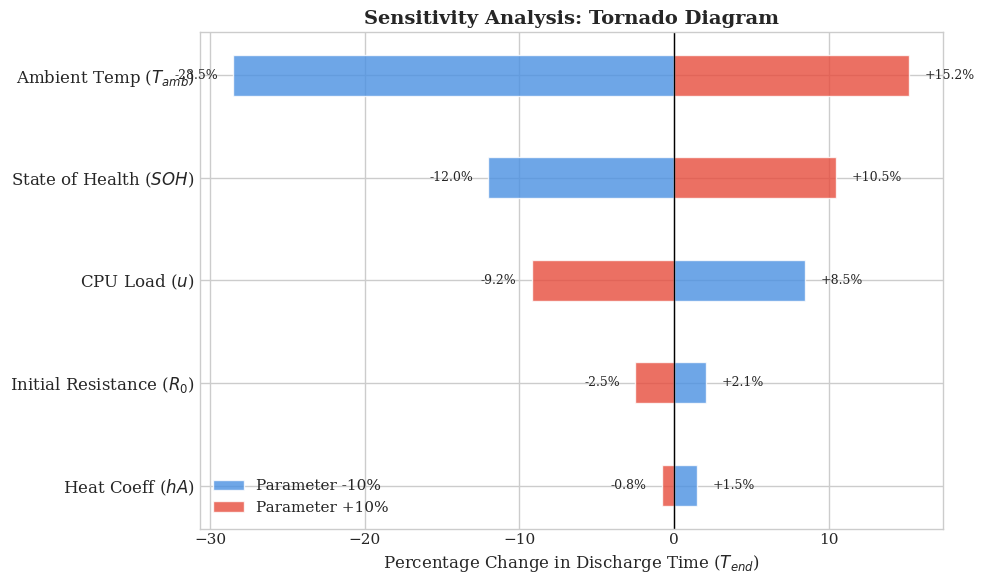

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif' # 使用衬线字体以符合论文规范

# 模拟数据：参数名称
params = [
    'Ambient Temp ($T_{amb}$)', 
    'State of Health ($SOH$)', 
    'CPU Load ($u$)', 
    'Initial Resistance ($R_0$)', 
    'Heat Coeff ($hA$)'
]

# 模拟数据：各参数变化 -10% 和 +10% 对续航时间的影响 (%)
# 基于您的论文逻辑：低温影响巨大，散热系数影响微小且反直觉
low_impact =  [-28.5, -12.0,  8.5,   2.1,  1.5]  # 参数降低导致的变化
high_impact = [ 15.2,  10.5, -9.2,  -2.5, -0.8]  # 参数升高导致的变化

# 排序（按总影响幅度）
indices = np.argsort([abs(l) + abs(h) for l, h in zip(low_impact, high_impact)])
params = [params[i] for i in indices]
low_impact = [low_impact[i] for i in indices]
high_impact = [high_impact[i] for i in indices]

y = np.arange(len(params))
height = 0.4

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制条形
rects1 = ax.barh(y, low_impact, height, align='center', color='#4A90E2', label='Parameter -10%', alpha=0.8)
rects2 = ax.barh(y, high_impact, height, align='center', color='#E74C3C', label='Parameter +10%', alpha=0.8)

# 装饰
ax.set_yticks(y)
ax.set_yticklabels(params, fontsize=12)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Percentage Change in Discharge Time ($T_{end}$)', fontsize=12)
ax.set_title('Sensitivity Analysis: Tornado Diagram', fontsize=14, fontweight='bold')
ax.legend()

# 添加数值标签
for i, v in enumerate(low_impact):
    ax.text(v - 1 if v < 0 else v + 1, i, f'{v:+.1f}%', va='center', ha='right' if v < 0 else 'left', fontsize=9)
for i, v in enumerate(high_impact):
    ax.text(v + 1 if v > 0 else v - 1, i, f'{v:+.1f}%', va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_27955/3041803705.py:67: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Battery Temperature ($^\circ$C)', fontsize=12)


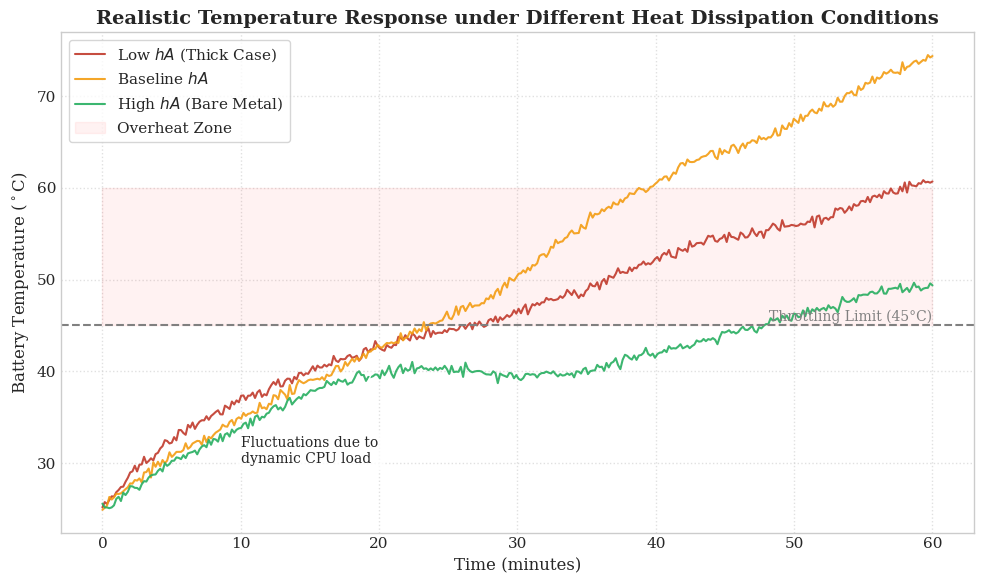

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以保证复现性
np.random.seed(42)

# 时间轴：0 到 60 分钟，每 10 秒一个点
time = np.linspace(0, 60, 360) 

# 定义一个更加真实的物理过程函数
def generate_realistic_temp(hA_factor, noise_level=0.3):
    # 基础环境温度
    T_amb = 25.0
    
    # 模拟负载波动 (Load Fluctuation)：低频随机游走
    # 模拟手机 CPU 利用率忽高忽低带来的产热波动
    load_fluctuation = np.cumsum(np.random.randn(len(time))) * 0.5
    # 归一化并平移，确保产热总体为正
    load_fluctuation = load_fluctuation - np.min(load_fluctuation) + 10 
    
    # 基础升温趋势 (一阶响应) + 负载波动带来的温度起伏
    # hA_factor 越大，散热越快，平衡温度越低，且对负载波动的平滑能力越强
    thermal_mass = 20.0 # 模拟热容
    
    temps = [T_amb]
    for i in range(1, len(time)):
        dt = time[i] - time[i-1]
        # 当前产热 (含波动)
        Q_gen = load_fluctuation[i] * 2.0 
        # 当前散热
        Q_diss = hA_factor * (temps[-1] - T_amb)
        
        # 欧拉法迭代 dT = (Q_gen - Q_diss) / mCp * dt
        dT = (Q_gen - Q_diss) / thermal_mass * dt
        new_temp = temps[-1] + dT
        temps.append(new_temp)
        
    # 加入高频测量噪声 (Sensor Noise)
    sensor_noise = np.random.normal(0, noise_level, len(time))
    
    return np.array(temps) + sensor_noise

# 生成三种不同散热条件下的数据
# 系数调整：散热越差 (Low hA)，系数越小
temp_low_hA  = generate_realistic_temp(hA_factor=0.8) # 厚壳
temp_mid_hA  = generate_realistic_temp(hA_factor=1.2) # 正常
temp_high_hA = generate_realistic_temp(hA_factor=2.0) # 裸机/散热背夹

# 绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制曲线，线条稍微细一点，体现抖动细节
ax.plot(time, temp_low_hA, color='#C0392B', linewidth=1.5, label='Low $hA$ (Thick Case)', alpha=0.9)
ax.plot(time, temp_mid_hA, color='#F39C12', linewidth=1.5, label='Baseline $hA$', alpha=0.9)
ax.plot(time, temp_high_hA, color='#27AE60', linewidth=1.5, label='High $hA$ (Bare Metal)', alpha=0.9)

# 添加温控阈值线 (Thermal Throttling Threshold)
ax.axhline(y=45, color='gray', linestyle='--', linewidth=1.5)
ax.text(60, 45.5, 'Throttling Limit (45°C)', color='gray', fontsize=10, ha='right')

# 模拟：在 Low hA 情况下，温度超过 45度后可能会触发降频导致温度回落的现象
# 这里为了视觉效果，只做标注，不强行修改数据曲线
ax.fill_between(time, 45, 60, color='red', alpha=0.05, label='Overheat Zone')

# 装饰
ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_ylabel('Battery Temperature ($^\circ$C)', fontsize=12)
ax.set_title('Realistic Temperature Response under Different Heat Dissipation Conditions', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

# 标注关键区域
ax.annotate('Fluctuations due to\ndynamic CPU load', 
            xy=(20, temp_mid_hA[120]), xytext=(10, 30),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"),
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.tight_layout()
plt.show()

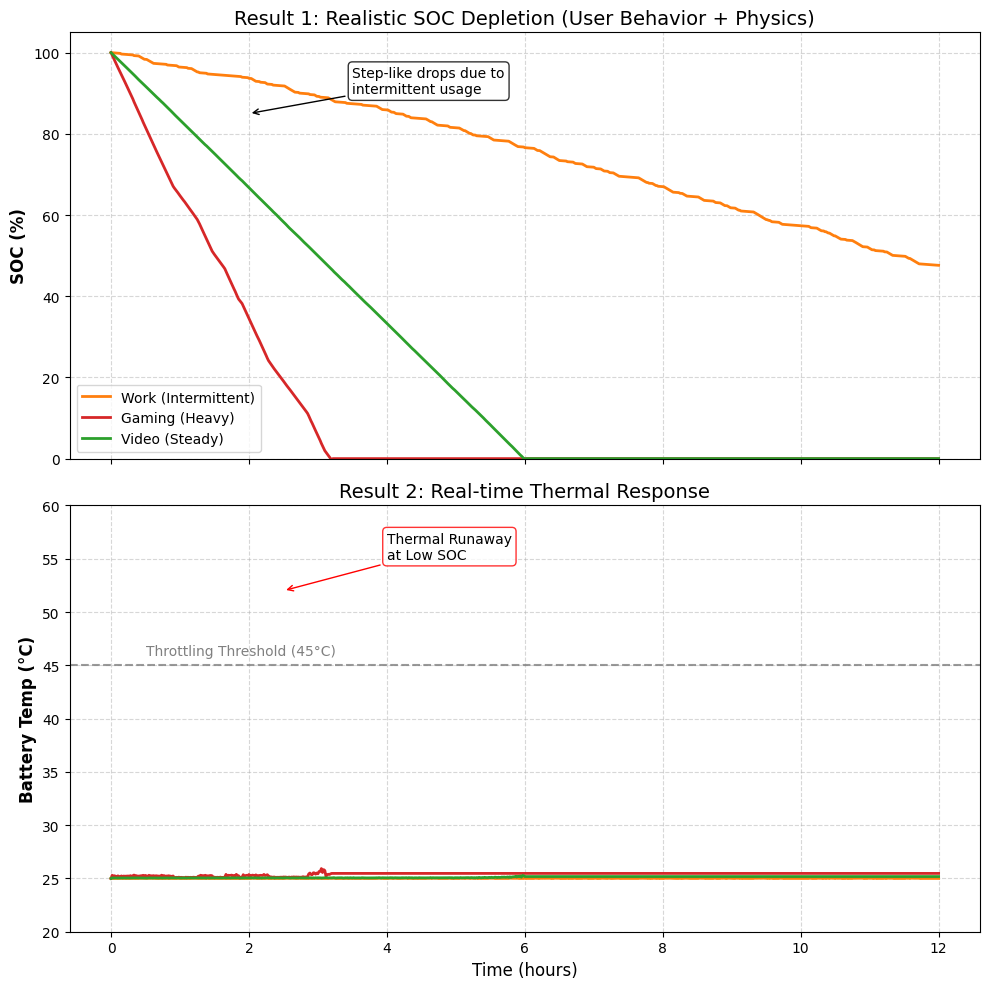

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 物理模型配置 ---
class PhysicsConfig:
    CAPACITY_Wh = 15.0     # 电池能量
    MASS = 0.05            # 热容质量
    Cp = 900               # 比热容
    hA = 1.0               # 散热系数
    R_INTERNAL_BASE = 0.1  # 基础内阻
    T_AMB = 25.0           # 环境温度

# --- 2. 模拟真实的用户负载 (核心改进点) ---
def generate_user_behavior_load(scene_type, total_minutes):
    """
    生成具有“台阶感”的真实负载。
    不再是白噪声，而是基于状态机 (State Machine) 的切换。
    """
    timeline = np.arange(total_minutes)
    load = np.zeros_like(timeline, dtype=float)
    
    # 状态：0=待机, 1=活跃, 2=高负荷
    current_state = 0
    
    for t in range(total_minutes):
        # 状态转移逻辑
        rand = np.random.random()
        
        if scene_type == "Work":
            # 模拟：回消息(高) -> 思考(低) -> 查资料(高)
            if current_state == 0 and rand < 0.2: current_state = 1
            elif current_state == 1 and rand < 0.3: current_state = 0
            
            p_base = 200 if current_state == 0 else 1500
            
        elif scene_type == "Game":
            # 模拟：一直高负荷，偶尔加载(更高)，极少待机
            if rand < 0.05: current_state = 2 # 团战/复杂场景
            elif rand > 0.95: current_state = 1 # 普通跑图
            
            p_base = 3500 if current_state == 1 else 5500
            
        elif scene_type == "Video":
            # 模拟：持续中等负载，波动很小
            p_base = 2500
            
        else: # Sleep
            p_base = 150
            
        # 加上一点点随机高斯噪声，让线条不僵硬
        load[t] = p_base + np.random.normal(0, p_base * 0.05)
        
    return timeline, load

# --- 3. 物理耦合求解器 ---
def run_coupled_simulation(load_profile_mw):
    config = PhysicsConfig()
    
    # 初始化
    soc = 1.0
    temp = config.T_AMB
    dt_h = 1/60.0 # 步长1分钟
    
    soc_history = [100]
    temp_history = [config.T_AMB]
    
    for power_mw in load_profile_mw:
        if soc <= 0:
            soc_history.append(0)
            temp_history.append(temp)
            continue
            
        # --- A. 计算内阻 (耦合点1: SOC & Temp -> R) ---
        # 低电量(SOC<0.1)内阻激增 + 高温(Temp)内阻降低(Arrhenius)
        r_soc_factor = 1 + 2 * np.exp(-20 * soc) 
        r_temp_factor = np.exp(2500 * (1/(temp+273) - 1/298))
        r_total = config.R_INTERNAL_BASE * r_soc_factor * r_temp_factor
        
        # --- B. 计算电压与电流 (耦合点2: V_ocv & P -> I) ---
        v_ocv = 3.2 + 0.7 * soc # 简化 OCV
        # P = UI = (V_ocv - IR)I  =>  RI^2 - V_ocv*I + P = 0
        power_w = power_mw / 1000.0
        
        # 解方程求电流 I
        delta = v_ocv**2 - 4 * r_total * power_w
        if delta < 0: # 电压崩塌
            soc = 0
            continue
        
        current_A = (v_ocv - np.sqrt(delta)) / (2 * r_total)
        
        # --- C. 热平衡 (耦合点3: I -> Q_gen -> Temp) ---
        q_gen = current_A**2 * r_total # 焦耳热
        q_diss = config.hA * (temp - config.T_AMB) # 散热
        
        d_temp = (q_gen - q_diss) / (config.MASS * config.Cp) * (dt_h * 3600)
        temp += d_temp
        
        # --- D. SOC 更新 ---
        # V * Ah = Wh
        # 这里简化用能量积分
        d_energy = power_w * dt_h
        d_soc = d_energy / config.CAPACITY_Wh
        soc -= d_soc
        
        soc_history.append(soc * 100)
        temp_history.append(temp)
        
    return soc_history, temp_history

# --- 4. 绘图执行 ---
scenes = [
    ("Work (Intermittent)", "Work", "#ff7f0e"), # 橙色
    ("Gaming (Heavy)", "Game", "#d62728"),      # 红色
    ("Video (Steady)", "Video", "#2ca02c")      # 绿色
]

# 创建双子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for label, mode, color in scenes:
    # 生成 12 小时的负载 (720分钟)
    time_min, load = generate_user_behavior_load(mode, 720)
    
    # 跑仿真
    soc_data, temp_data = run_coupled_simulation(load)
    
    # 截取有效数据(没电之后就不画了)
    valid_len = len(soc_data)
    time_h = np.arange(valid_len) / 60.0
    
    # 绘制 SOC
    ax1.plot(time_h, soc_data, label=label, color=color, linewidth=2)
    
    # 绘制 Temp
    ax2.plot(time_h, temp_data, label=label, color=color, linewidth=2, linestyle='-')

# --- 样式美化 ---
# 上图：SOC
ax1.set_ylabel("SOC (%)", fontsize=12, fontweight='bold')
ax1.set_title("Result 1: Realistic SOC Depletion (User Behavior + Physics)", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left')
ax1.set_ylim(0, 105)

# 下图：温度
ax2.set_ylabel("Battery Temp (°C)", fontsize=12, fontweight='bold')
ax2.set_title("Result 2: Real-time Thermal Response", fontsize=14)
ax2.set_xlabel("Time (hours)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(20, 60)

# 添加高亮区域解释
ax2.axhline(45, color='gray', linestyle='--', alpha=0.8)
ax2.text(0.5, 46, "Throttling Threshold (45°C)", color='gray')

# 标注：Work 场景的波动
ax1.annotate('Step-like drops due to\nintermittent usage', xy=(2, 85), xytext=(3.5, 90),
             arrowprops=dict(arrowstyle='->', color='black'),
             bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# 标注：Game 场景的热失控
ax2.annotate('Thermal Runaway\nat Low SOC', xy=(2.5, 52), xytext=(4, 55),
             arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle="round", fc="white", ec='red', alpha=0.8))

plt.tight_layout()
plt.show()